In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import numpy as np
from util import *

%load_ext autoreload    
%autoreload 2

In [27]:
'''
This file is to calculate RMM index from flt120d anomaly daily data
'''
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt
from datetime import datetime
import scipy.fft as fft 
import pandas as pd 

import multiprocessing
from util import get_RMMEOF, get_RMM

# we will get data anomalies for periods of date_sta to date_end
year_sta = '1978'
year_end = '2025'
# this indicates which years are used to get the annual cycle.
yearclim_sta=1979
yearclim_end=2001
eof_lat = 15
flg = ''
data_store = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/'

dseof = xr.open_dataset(data_store+'RMMeof_ERA5_daily_'+str(yearclim_sta)+'to'+str(yearclim_end)+flg+'.nc')
EOF_RMM_field1 = dseof['EOF']

In [28]:
EOF_RMM_field1

<xarray.DataArray 'EOF' (lon: 540, mode: 2)>
[1080 values with dtype=float64]
Coordinates:
  * mode     (mode) int64 0 1
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
Attributes:
    long_name:  empirical_orthogonal_functions

In [38]:
EOF_WH04 = np.array(np.loadtxt('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_EOF_values.txt'))
x = EOF_RMM_field1.lon[:180].values 
# eof_olr = EOF_RMM_field1[:180,:].values 
# eof_u850 = EOF_RMM_field1[180:180*2,:].values
# eof_u200 = EOF_RMM_field1[180*2:180*3,:].values

klon0 = 144
eof_olr = EOF_WH04[:klon0,:]
eof_u850 = EOF_WH04[klon0:klon0*2,:]
eof_u200 = EOF_WH04[klon0*2:klon0*3,:]
x0 = np.linspace(0,360,klon0)

# interpolate
from scipy.interpolate import interp1d
f = interp1d(x0, eof_olr, axis=0)
eof_olr = f(x)
f = interp1d(x0, eof_u850, axis=0)
eof_u850 = f(x)
f = interp1d(x0, eof_u200, axis=0)
eof_u200 = f(x)

eof_u200.shape 

EOF_WH04_interp = np.concatenate([eof_olr,eof_u850,eof_u200],axis=0)
EOF_WH04_interp.shape

EOF_RMM_field1.values = EOF_WH04_interp

In [39]:
ds = xr.open_dataset(data_store+'RMMfield_ERA5_daily_'+str(yearclim_sta)+'to'+str(yearclim_end)+flg+'.nc')
RMM_field = ds['RMM_field']

get_RMM(RMM_field, EOF_RMM_field1, str(yearclim_sta)+'-01-01',str(yearclim_end)+'-12-31',flg='WH04EOF')

<xarray.DataArray (mode: 2)>
array([9.22286572, 9.20164781])
Coordinates:
  * mode     (mode) int64 0 1


In [25]:
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/uwnd.1978.nc'
ds = xr.open_dataset(fn)
ds 

<xarray.Dataset>
Dimensions:    (level: 17, lat: 73, lon: 144, time: 365, nbnds: 2)
Coordinates:
  * level      (level) float32 1e+03 925.0 850.0 700.0 ... 50.0 30.0 20.0 10.0
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1978-01-01 1978-01-02 ... 1978-12-31
Dimensions without coordinates: nbnds
Data variables:
    uwnd       (time, level, lat, lon) float32 ...
    time_bnds  (time, nbnds) float64 ...
Attributes:
    Conventions:    COARDS
    title:          mean daily NMC reanalysis (1978)
    description:    Data is from NMC initialized reanalysis\n(4x/day).  It co...
    platform:       Model
    history:        created 95/02/06 by Hoop (netCDF2.3)\nConverted to chunke...
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [18]:
# we will get data anomalies for periods of date_sta to date_end
year_sta = '1980'
year_end = '2025'
# this indicates which years are used to get the annual cycle.
yearclim_sta=1980
yearclim_end=2001
fnolr = f'/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/olr_ano.15d.30S-30N.nc'
fnu850 = f'/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/u850_ano.15d.30S-30N.nc'
fnu200 = f'/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/u200_ano.15d.30S-30N.nc'

get_RMM_usingKimsInput(fnolr, fnu850, fnu200, eof_sta=19800101)

stdolr:  0.6352287137082168
stdu850:  0.5737667746215256
stdu200:  0.6418520214136718
variance fraction:  [21.83914528 12.84727219  6.33784024  5.13169258  3.87181105]
Standard deviation of PCs (pcs_scale): [[9.71314098 7.4498467 ]]


In [13]:
# compare Kim's u850 with ours 
f1 = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/fltano120/olr.fltano120.1978to2025based1979to2001.nc'
f2 = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/olr_ano.15d.30S-30N.nc'

ds1 = xr.open_dataset(f1)
ds2 = xr.open_dataset(f2)

In [22]:
ds2 

<xarray.Dataset>
Dimensions:  (time: 4729, lat: 25, lon: 144)
Coordinates:
  * time     (time) int32 19791116 19791117 19791118 ... 20180315 20180316
  * lat      (lat) float32 -30.0 -27.5 -25.0 -22.5 -20.0 ... 22.5 25.0 27.5 30.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Data variables:
    olr_ano  (time, lat, lon) float64 ...

In [14]:
norm_var = ds1['olr'].sel(time=slice('1979-01-01', '2001-12-31')).std()
norm_var

<xarray.DataArray 'olr' ()>
array(21.86305699)

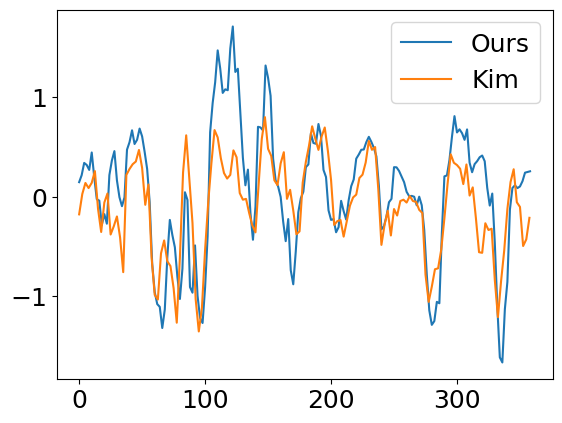

In [15]:
u1 = ds1['olr'].sel(time='2001-01-01',lat=slice(15,-15)).mean('lat')
u2 = ds2['olr_ano'].sel(time=20010101,lat=slice(-15,15)).mean('lat')

fig, ax = plt.subplots()
ax.plot(u1.lon, u1 / norm_var.values,label='Ours')
ax.plot(u2.lon, u2,label='Kim')
ax.legend()


In [6]:
EOF_RMM_field1.shape[0]/3

144.0

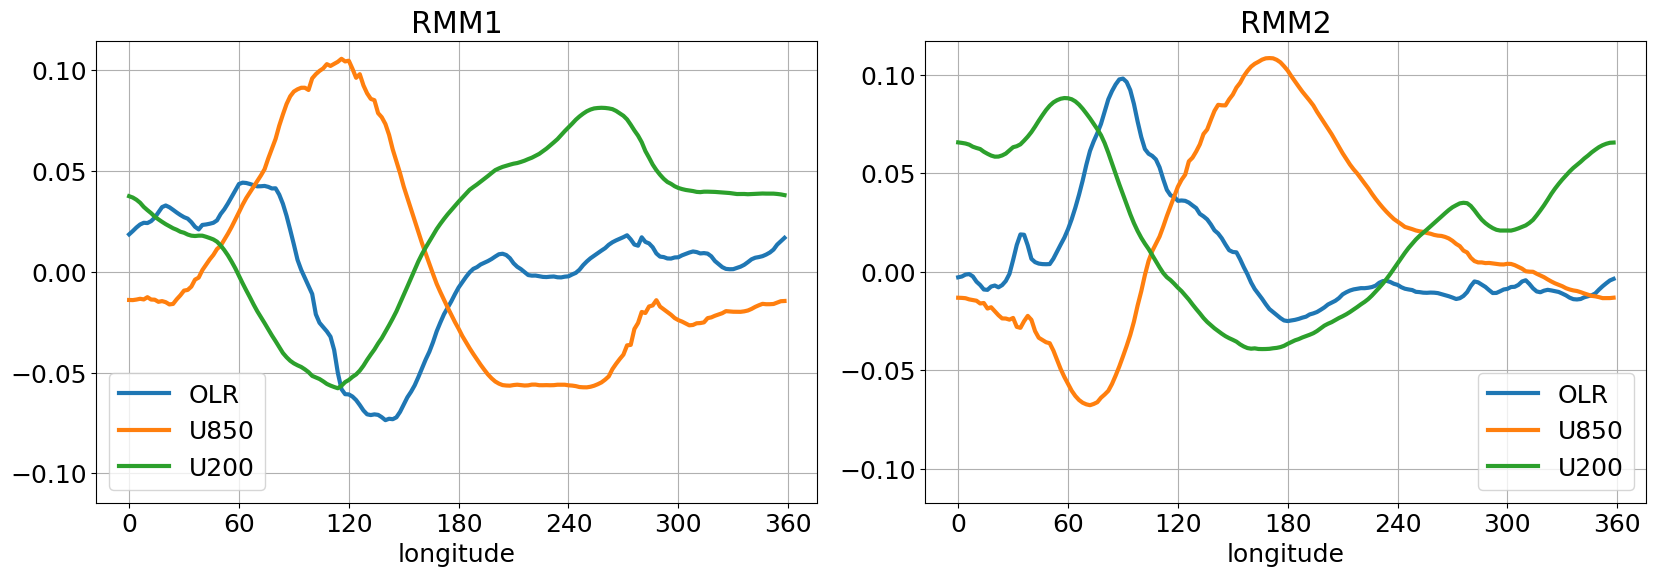

In [3]:

yearclim_sta=1979
yearclim_end=2001

dseof = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMMeof_ERA5_daily_1980to2001.noaa.nc')
# dseof = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMMeof_ERA5_daily_1979to2001.nc')
EOF_RMM_field1 = dseof['EOF']
klon = EOF_RMM_field1.shape[0]//3
# plot the EOF of three maps to check. 
plt.rcParams.update({'font.size': 18})
fig = plt.figure(figsize=(20,6))
gs = fig.add_gridspec(1, 2, wspace=0.15)
ax = gs.subplots()

for i in range(2):
  ax[i].plot(EOF_RMM_field1[:klon,i].lon, EOF_RMM_field1[:klon,i], linewidth=3, label='OLR')
  ax[i].plot(EOF_RMM_field1[klon:klon*2,i].lon, EOF_RMM_field1[klon:klon*2,i], linewidth=3, label='U850')
  ax[i].plot(EOF_RMM_field1[klon*2:klon*3,i].lon, EOF_RMM_field1[klon*2:klon*3,i], linewidth=3, label='U200')
  ax[i].set_title('RMM'+str(i+1))
  ax[i].set_xlabel('longitude')
  ax[i].grid(visible=True)
  yabs_max = abs(max(ax[i].get_ylim(), key=abs))
  ax[i].set_xticks(np.arange(0, 361, 60))
  ax[i].set_ylim(ymin=-yabs_max, ymax=yabs_max)
  ax[i].legend()

# # dseof = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMMeof_KIM_daily_1979to2001.nc')
# # dseof = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/RMMeof_ERA5_daily_1979to2001.nc')
# # dseof = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMMeof_ERA5_daily_1979to2001.nc')
# dseof = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMMeof_ERA5_daily_1980to2001.noaa.nc')
# EOF_RMM_field1 = dseof['EOF']

# klon = EOF_RMM_field1.shape[0]//3
# for i in range(2):
#   ax[i].plot(EOF_RMM_field1[:klon,i].lon, EOF_RMM_field1[:klon,i], linewidth=3, linestyle='dashed', label='OLR', color='tab:blue')
#   ax[i].plot(EOF_RMM_field1[klon:klon*2,i].lon, EOF_RMM_field1[klon:klon*2,i], linewidth=3, linestyle='dashed', label='U850', color='tab:orange')
#   ax[i].plot(EOF_RMM_field1[klon*2:klon*3,i].lon, EOF_RMM_field1[klon*2:klon*3,i], linewidth=3, linestyle='dashed', label='U200', color='tab:green')
#   ax[i].set_title('RMM'+str(i+1))
#   ax[i].set_xlabel('longitude')
#   ax[i].grid(visible=True)
#   yabs_max = abs(max(ax[i].get_ylim(), key=abs))
#   ax[i].set_xticks(np.arange(0, 361, 30))
#   ax[i].set_ylim(ymin=-yabs_max, ymax=yabs_max)
#   # ax[i].legend()

# ax[1].legend()

In [4]:
import xarray as xr
import matplotlib.pyplot as plt 
from util import mjo_phase_background


datesta = '2015-03-01'
dateend = '2015-04-01'

ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001WH04EOF.nc')
RMM_WH04 = ds['RMM'].sel(time=slice(datesta,dateend))

ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_KIM_daily_1979to2001.nc')
RMM_old = ds['RMM'].sel(time=slice(20150301,20150401))

# ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001.nc')
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1980to2001.noaa.nc')
RMM_new = ds['RMM'].sel(time=slice(datesta,dateend))



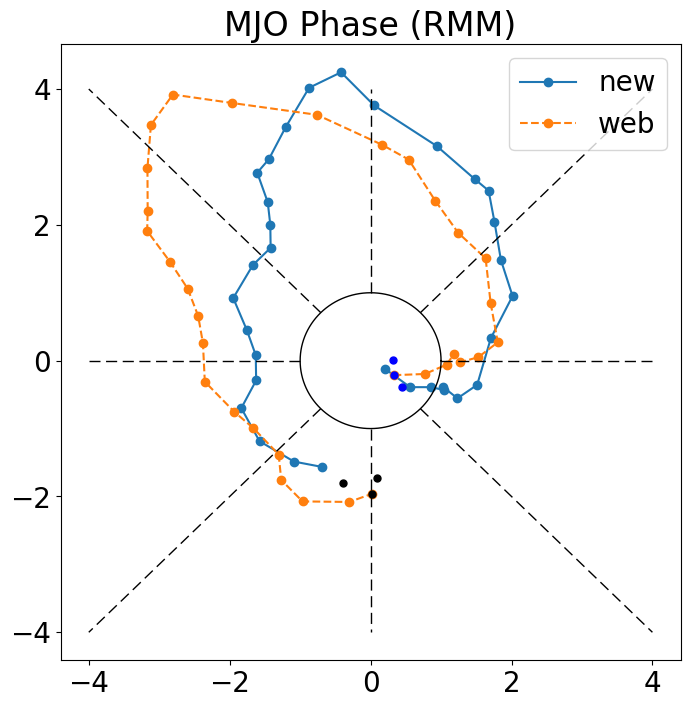

In [5]:
import numpy as np

pc1 = RMM_new[:,0]
pc2 = RMM_new[:,1]
time = RMM_old['time']
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


# Define a colormap for the months
cmap = plt.cm.get_cmap('tab10')
plt.rcParams.update({'font.size': 20})
# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title(f"MJO Phase (RMM)")

ax.plot(pc1, pc2, 'o-', label='new')
# Mark the first and last points
# ax.plot(pc1[0], pc2[0], 'o', color="black", **plMark)
# ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)


pc1 = xr.open_dataarray('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/output.rmm1.nc').sel(time=slice(20150301,20150501)).values
pc2 = xr.open_dataarray('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/output.rmm2.nc').sel(time=slice(20150301,20150501)).values

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


# Define a colormap for the months
cmap = plt.cm.get_cmap('tab10')
plt.rcParams.update({'font.size': 20})
# Plot
# fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title(f"MJO Phase (RMM)")

# ax.plot(pc1, pc2, 'o-', label='Kim')
# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="blue", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)


#####
# pc1 = RMM_new[:,0]
# pc2 = RMM_new[:,1]

pc1 = RMM_WH04[:,0]
pc2 = RMM_WH04[:,1]
time = RMM_new['time']
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


# Define a colormap for the months
cmap = plt.cm.get_cmap('tab10')
plt.rcParams.update({'font.size': 20})
# ax.plot(pc1, pc2, 'o-', label='WH04')


# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="blue", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)

filename = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/rmm.74toRealtime.txt'
data = []  # List to store the data

with open(filename, "r") as file:
    next(file)  # Skip the first line with the header
    next(file)
    for line in file:
        values = line.split()
        year = int(values[0])
        month = int(values[1])
        day = int(values[2])
        rmm1 = float(values[3]) if values[3] != "1.E36" else None
        rmm2 = float(values[4]) if values[4] != "1.E36" else None
        phase = int(values[5])
        amplitude = float(values[6]) if values[6] != "1.E36" else None
    
        data.append([pd.Timestamp(year=year, month=month, day=day), rmm1, rmm2, phase, amplitude])

# Create DataFrame from the collected data
columns = ["Date", "RMM1", "RMM2", "Phase", "Amplitude"]
df = pd.DataFrame(data, columns=columns)
df_sel = df[(df['Date'] >= datesta) & (df['Date'] <= dateend)]
RMM1web = np.asarray(df_sel['RMM1'])
RMM2web = np.asarray(df_sel['RMM2'])
pc1 = RMM1web[:100]
pc2 = RMM2web[:100]
time = RMM_new['time'][:100]
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


ax.plot(pc1, pc2, 'o--', label='web')

# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="blue", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)

ax.legend()
mjo_phase_background(ax)
plt.show()

In [6]:
import pandas as pd 
datesta = '1980-01-01'
dateend = '2022-12-31'
# ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001.nc')
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1980to2001.noaa.nc')
RMM_new = ds['RMM'].sel(time=slice(datesta,dateend))
time = RMM_new['time']

filename = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/rmm.74toRealtime.txt'
data = []  # List to store the data

with open(filename, "r") as file:
    next(file)  # Skip the first line with the header
    next(file)
    for line in file:
        values = line.split()
        year = int(values[0])
        month = int(values[1])
        day = int(values[2])
        rmm1 = float(values[3]) if values[3] != "1.E36" else None
        rmm2 = float(values[4]) if values[4] != "1.E36" else None
        phase = int(values[5])
        amplitude = float(values[6]) if values[6] != "1.E36" else None
    
        data.append([pd.Timestamp(year=year, month=month, day=day), rmm1, rmm2, phase, amplitude])

# Create DataFrame from the collected data
columns = ["Date", "RMM1", "RMM2", "Phase", "Amplitude"]
df = pd.DataFrame(data, columns=columns)
df_sel = df[(df['Date'] >= datesta) & (df['Date'] <= dateend)]
RMM1web = np.asarray(df_sel['RMM1'])
RMM2web = np.asarray(df_sel['RMM2'])

print('lenth of web', len(RMM1web))
print('lenth of new', len(RMM_new))

lenth of web 15706
lenth of new 15706


In [7]:
bcc = (np.sum(RMM_new[:,0] * RMM1web + RMM_new[:,1]*RMM2web))/(np.sqrt(np.sum(RMM_new[:,0]**2+RMM_new[:,1]**2)) * np.sqrt(np.sum(RMM1web**2+RMM2web**2)))
bcc 

<xarray.DataArray 'RMM' ()>
array(0.81517494)

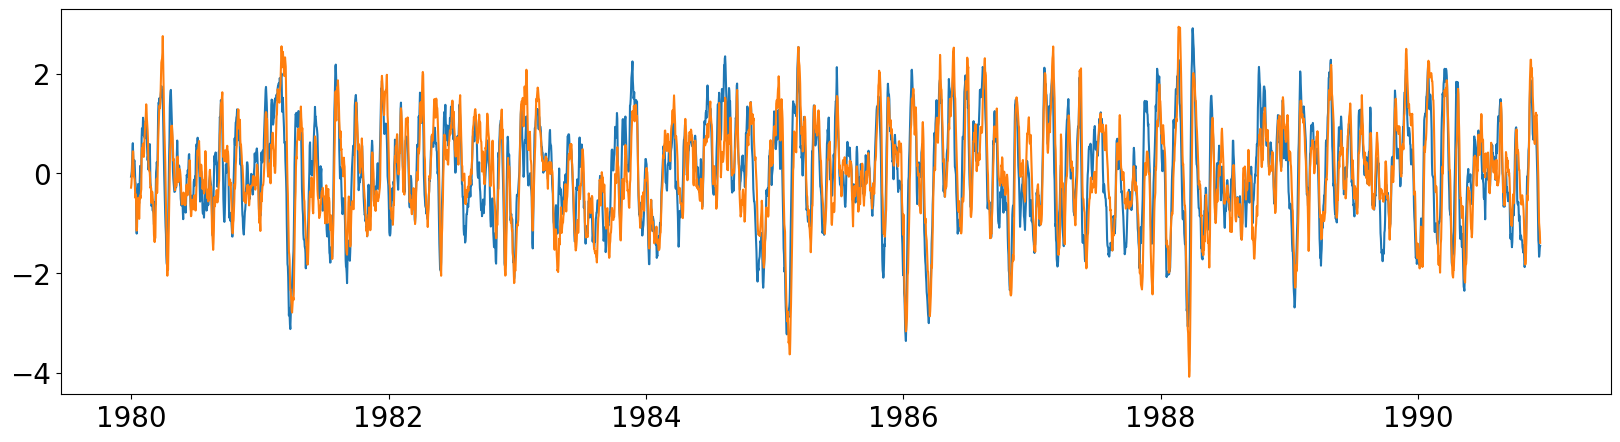

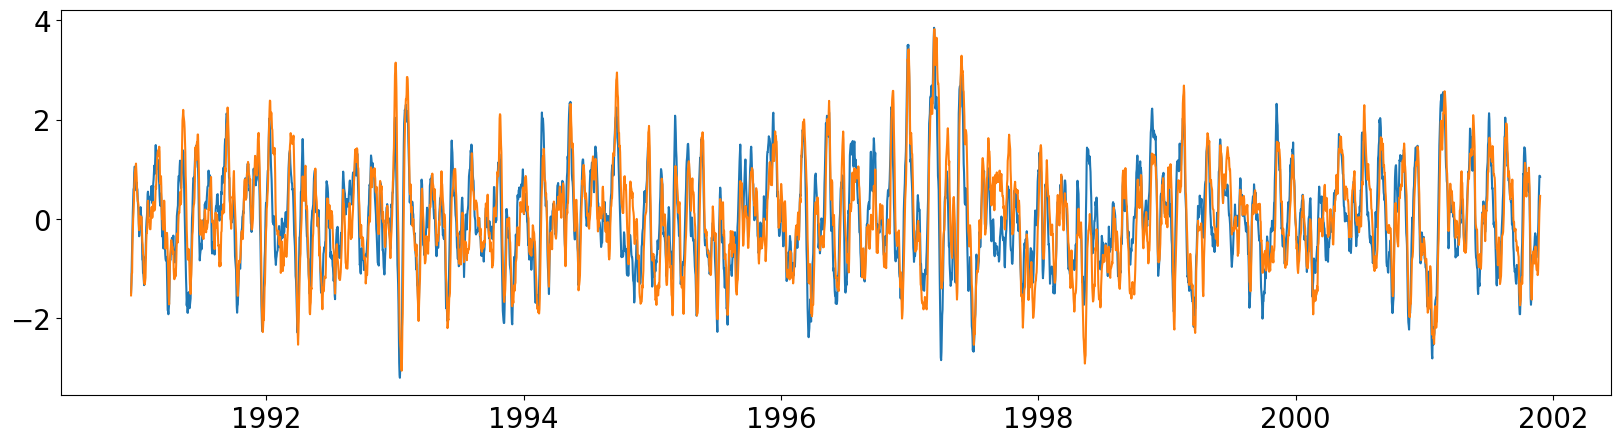

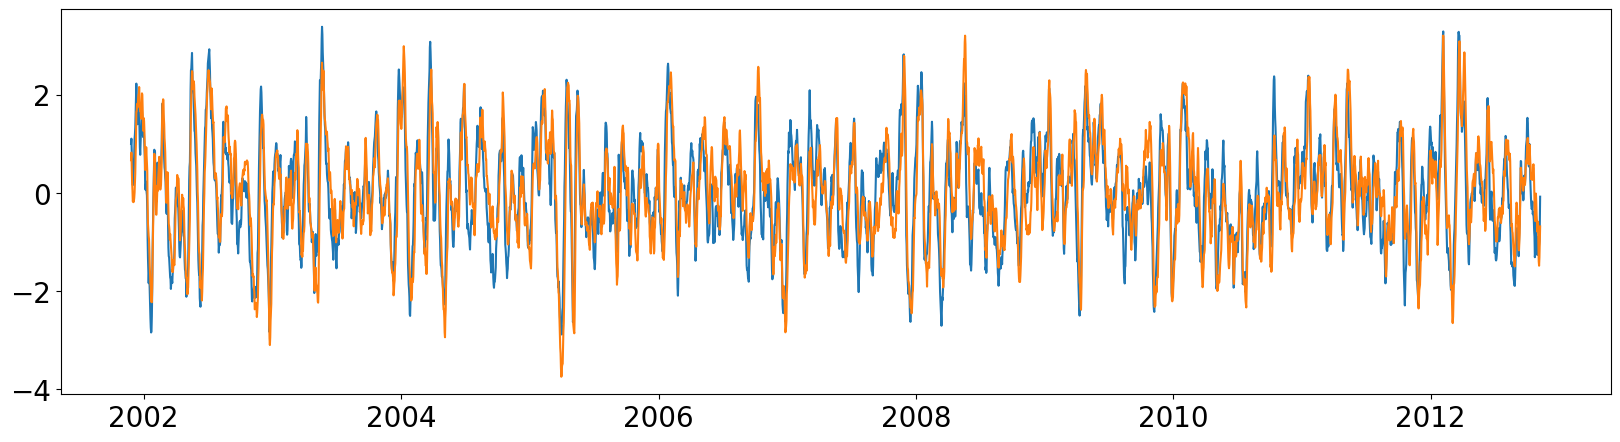

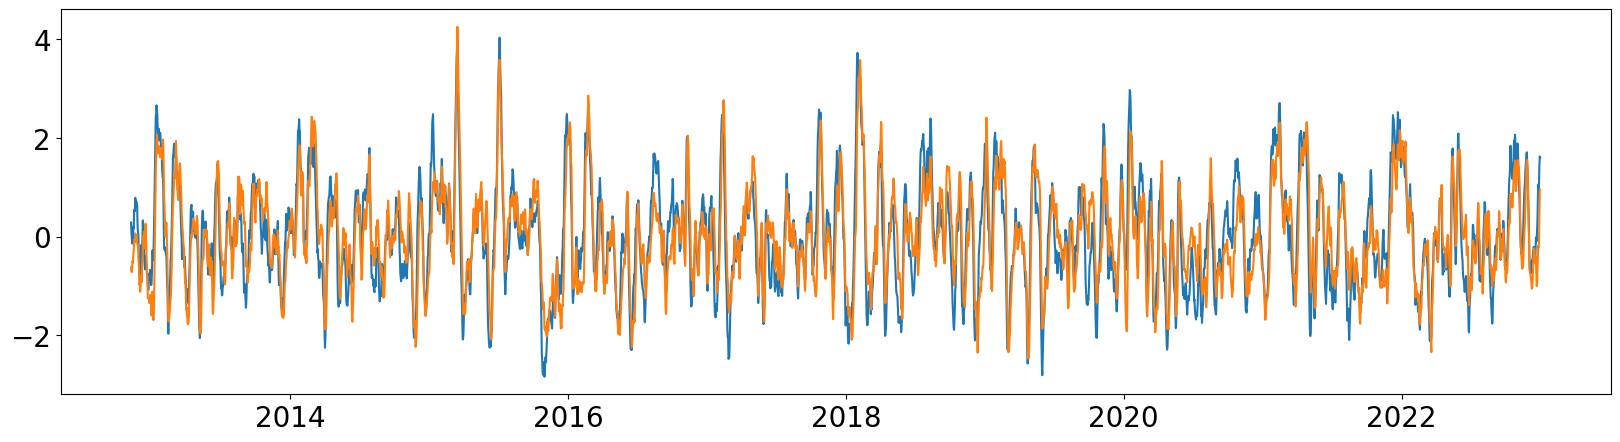

In [8]:
fig, ax = plt.subplots(figsize=(20,5))
ax.plot(time[:4000], RMM2web[:4000], label='web')
ax.plot(time[:4000], RMM_new[:,1][:4000], label='new')
fig, ax = plt.subplots(figsize=(20,5))
ax.plot(time[4000:8000], RMM2web[4000:8000], label='web')
ax.plot(time[4000:8000], RMM_new[:,1][4000:8000], label='new')
fig, ax = plt.subplots(figsize=(20,5))
ax.plot(time[8000:12000], RMM2web[8000:12000], label='web')
ax.plot(time[8000:12000], RMM_new[:,1][8000:12000], label='new')
fig, ax = plt.subplots(figsize=(20,5))
ax.plot(time[12000:], RMM2web[12000:], label='web')
ax.plot(time[12000:], RMM_new[:,1][12000:], label='new')


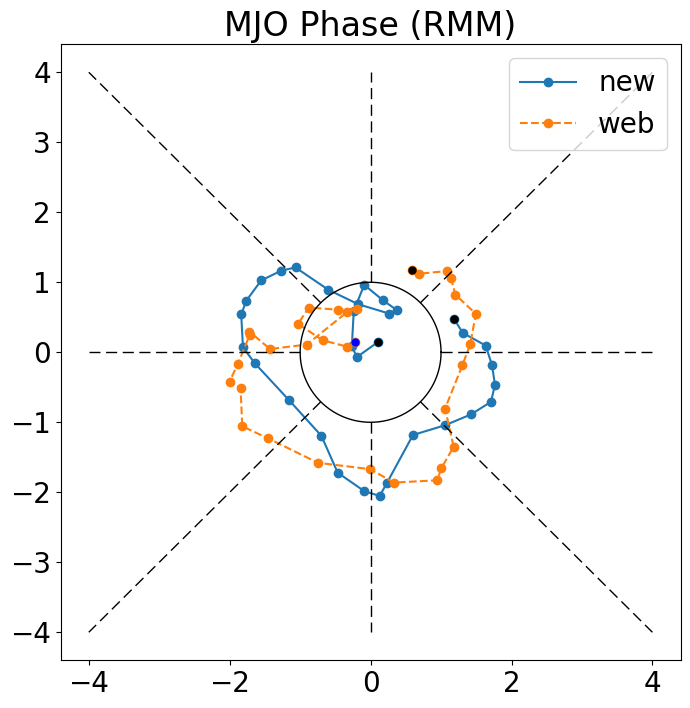

In [9]:
import numpy as np

datesta = '1999-01-01'
dateend = '1999-02-01'

ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001.nc')
RMM_new = ds['RMM'].sel(time=slice(datesta,dateend))


pc1 = RMM_new[:,0]
pc2 = RMM_new[:,1]
time = RMM_new['time']
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


# Define a colormap for the months
cmap = plt.cm.get_cmap('tab10')
plt.rcParams.update({'font.size': 20})
# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title(f"MJO Phase (RMM)")

ax.plot(pc1, pc2, 'o-', label='new')
# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="black", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)


filename = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/rmm.74toRealtime.txt'
data = []  # List to store the data

with open(filename, "r") as file:
    next(file)  # Skip the first line with the header
    next(file)
    for line in file:
        values = line.split()
        year = int(values[0])
        month = int(values[1])
        day = int(values[2])
        rmm1 = float(values[3]) if values[3] != "1.E36" else None
        rmm2 = float(values[4]) if values[4] != "1.E36" else None
        phase = int(values[5])
        amplitude = float(values[6]) if values[6] != "1.E36" else None
    
        data.append([pd.Timestamp(year=year, month=month, day=day), rmm1, rmm2, phase, amplitude])

# Create DataFrame from the collected data
columns = ["Date", "RMM1", "RMM2", "Phase", "Amplitude"]
df = pd.DataFrame(data, columns=columns)
df_sel = df[(df['Date'] >= datesta) & (df['Date'] <= dateend)]
RMM1web = np.asarray(df_sel['RMM1'])
RMM2web = np.asarray(df_sel['RMM2'])
pc1 = RMM1web[:100]
pc2 = RMM2web[:100]
time = RMM_new['time'][:100]
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


ax.plot(pc1, pc2, 'o--', label='web')

# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="blue", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)

ax.legend()
mjo_phase_background(ax)
plt.show()

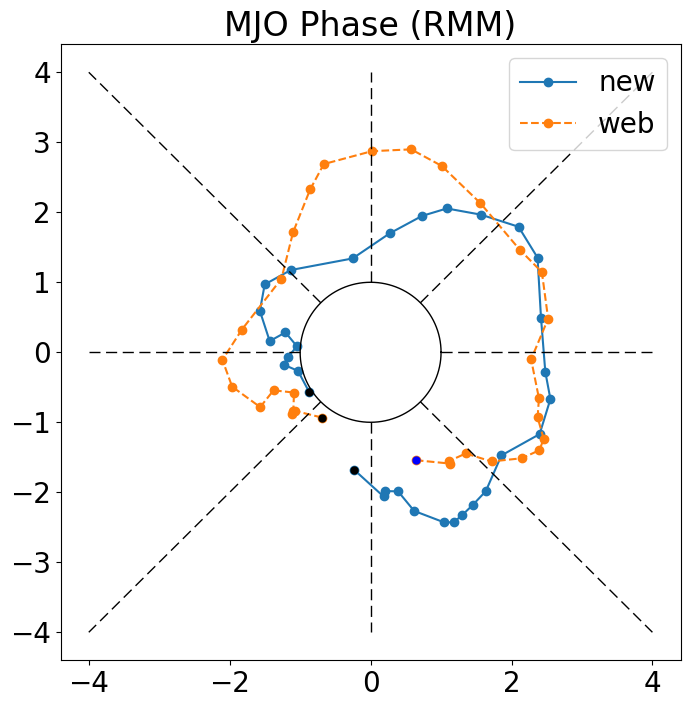

In [15]:
import numpy as np

datesta = '2024-03-01'
dateend = '2024-04-01'

ds = xr.open_dataset('/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/rmm/RMM_ERA5_daily_1979to2001.nc')
RMM_new = ds['RMM'].sel(time=slice(datesta,dateend))


pc1 = RMM_new[:,0]
pc2 = RMM_new[:,1]
time = RMM_old['time']
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


# Define a colormap for the months
cmap = plt.cm.get_cmap('tab10')
plt.rcParams.update({'font.size': 20})
# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title(f"MJO Phase (RMM)")

ax.plot(pc1, pc2, 'o-', label='new')
# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="black", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)


filename = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/scripts/data_proc/RMM_cal/WH04_reproduce/rmm.74toRealtime.txt'
data = []  # List to store the data

with open(filename, "r") as file:
    next(file)  # Skip the first line with the header
    next(file)
    for line in file:
        values = line.split()
        year = int(values[0])
        month = int(values[1])
        day = int(values[2])
        rmm1 = float(values[3]) if values[3] != "1.E36" else None
        rmm2 = float(values[4]) if values[4] != "1.E36" else None
        phase = int(values[5])
        amplitude = float(values[6]) if values[6] != "1.E36" else None
    
        data.append([pd.Timestamp(year=year, month=month, day=day), rmm1, rmm2, phase, amplitude])

# Create DataFrame from the collected data
columns = ["Date", "RMM1", "RMM2", "Phase", "Amplitude"]
df = pd.DataFrame(data, columns=columns)
df_sel = df[(df['Date'] >= datesta) & (df['Date'] <= dateend)]
RMM1web = np.asarray(df_sel['RMM1'])
RMM2web = np.asarray(df_sel['RMM2'])
pc1 = RMM1web[:100]
pc2 = RMM2web[:100]
time = RMM_new['time'][:100]
ntim = len(time)

plMark = dict(markersize=5)
plLine = dict(linewidth=1.0)
txres = dict(fontsize=10)

# Convert the time column to datetime format
import pandas as pd 
time = pd.to_datetime(time)


ax.plot(pc1, pc2, 'o--', label='web')

# Mark the first and last points
ax.plot(pc1[0], pc2[0], 'o', color="blue", **plMark)
ax.plot(pc1[-1], pc2[-1], 'o', color="black", **plMark)

ax.legend()
mjo_phase_background(ax)
plt.show()